In [1]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
csv0=r"C:\Users\Administrator\Desktop\Chess\player-cluster\player_style_results_chaos.csv"
csv1=r"C:\Users\Administrator\Desktop\Chess\player-cluster\player_style_results_solid.csv"
csv2=r"C:\Users\Administrator\Desktop\Chess\player-cluster\player_style_results_forcing.csv"
csv3=r"C:\Users\Administrator\Desktop\Chess\player-cluster\player_style_results_tactical.csv"

In [4]:
df0 = pd.read_csv(csv0)
df1 = pd.read_csv(csv1)
df2 = pd.read_csv(csv2)
df3 = pd.read_csv(csv3)

df_all = (
    df0
    .merge(df1, on="Name", how="left")
    .merge(df2, on="Name", how="left")
    .merge(df3[['Name', 'tactical_Style_Prob']], on="Name", how="left")
)

print(df_all.shape)
print(df_all.head())

(2695, 5)
                Name  Chaos_Style_Prob  Solid_Style_Prob  Forcing_Style_Prob  \
0       4empechement          0.585750          0.375859            0.275133   
1  AFRUZA Khamdamova          0.892466          0.106052            0.419986   
2       Aadit Bhatia          0.905979          0.068186            0.870713   
3    Aaditya Dhingra          0.410052          0.598937            0.866760   
4     Aakaash Meduri          0.923414          0.070110            0.887610   

   tactical_Style_Prob  
0             0.389314  
1             0.628052  
2             0.734174  
3             0.858479  
4             0.620631  


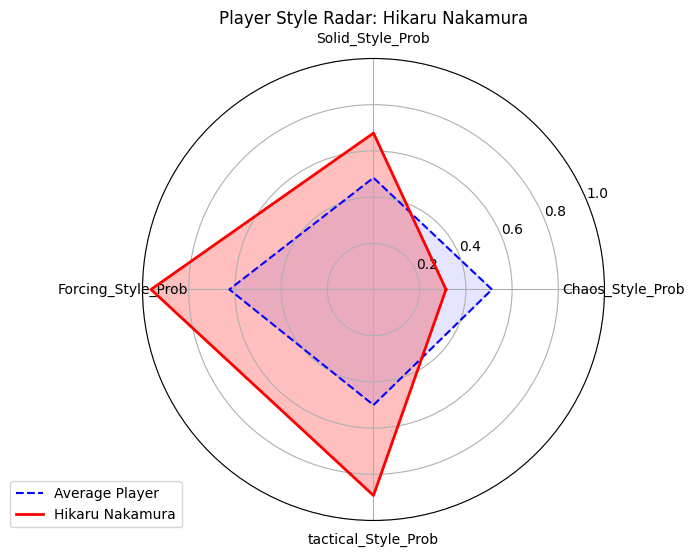

In [8]:
style_cols = [col for col in df_all.columns if col != "Name"]
average_scores = df_all[style_cols].mean().values

player_name = "Hikaru Nakamura"  # 比如你想画 "MagnusCarlsen"
player = df_all[df_all['Name'] == player_name].iloc[0]
player_scores = player[style_cols].values

num_vars = len(style_cols)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
#雷达图
player_scores = np.concatenate((player_scores, [player_scores[0]]))
average_scores = np.concatenate((average_scores, [average_scores[0]]))
angles += angles[:1]
fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

ax.plot(angles, average_scores, color='blue', linewidth=1.5, linestyle='--', label='Average Player')
ax.fill(angles, average_scores, color='blue', alpha=0.1) # alpha=0.1 让填充非常淡

ax.plot(angles, player_scores, color='r', linewidth=2, linestyle='solid', label=player_name)
ax.fill(angles, player_scores, color='r', alpha=0.25)

#刻度标签
ax.set_xticks(angles[:-1])
ax.set_xticklabels(style_cols)
ax.set_ylim(0, 1)

plt.title(f"Player Style Radar: {player_name}")
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()
